# 10 — IMDb-derived full general-vector QSVT 真机 pilot

这一章把 `07` 的 active general-vector NumPy 算法逐门展开为一个完整的
$D=4$ 线路：

$$
|+\rangle_{\rm data}
\longrightarrow
\text{sample-driven }B_g
\longrightarrow
\text{degree-4 arcsin QSVT}
\longrightarrow
\frac{V+V^\dagger}{2}
\longrightarrow
O_hH^{\otimes 2} .
$$

它包含论文代码所说的两个算法辅助位：

- `signal`：第一层 sine LCU / QSVT；
- `real`：第二层 LCU，提取 $V_{00}$ 的实部。

这里不是用 `StatePreparation` 冒充 QOS。每个样本都变成
$\exp(i\alpha Y_{\rm signal}Z^j)$ Pauli-string rotation。只有在独立的
`verify` 版本末尾，才附加已知目标态的 inverse，专门把条件 fidelity 转成
可测的全零概率。

这是一个真实可提交的 **小规模 gate-level proof-of-principle**。静态 QASM
预存了样本流，而且受控 $V/V^\dagger$ 很深；它不代表 IMDb 规模的端到端
量子分类或系统级空间优势。

In [1]:
from pathlib import Path
from getpass import getpass
from importlib.metadata import version
from datetime import datetime, timezone
import hashlib
import json
import os
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import (
    ClassicalRegister,
    QuantumCircuit,
    QuantumRegister,
    qasm2,
    transpile,
)
from qiskit.circuit import Gate
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Operator, Statevector
from qiskit_aer import AerSimulator

SEED = 20260729
DEGREE = 4
S_SHOTS = 8192
QSVT_ANGLES = np.array([
    0.8146660202963166,
    2.013676437831353,
    2.013676437831353,
    0.8146660202963166,
])

TARGET_PATH = Path(
    "../results/imdb_vector_pilot/imdb_d4_target.json"
)
BUNDLE = Path("../results/general_vector_qsvt_pilot")
QASM_DIR = BUNDLE / "qasm"
FIGURES = Path("../assets/figures")
CIRCUITS = Path("../assets/circuits")
for directory in (BUNDLE, QASM_DIR, FIGURES, CIRCUITS):
    directory.mkdir(parents=True, exist_ok=True)

if not TARGET_PATH.exists():
    raise FileNotFoundError(
        "Run 09_quafu_imdb_vector_pilot.ipynb first: "
        f"missing {TARGET_PATH}"
    )

target_meta = json.loads(TARGET_PATH.read_text(encoding="utf-8"))
target_sha256 = hashlib.sha256(TARGET_PATH.read_bytes()).hexdigest()
raw_vector = np.asarray(target_meta["raw_vector"], dtype=np.float64)
target = np.asarray(
    target_meta["normalized_vector"], dtype=np.float64
)
target /= np.linalg.norm(target)
if len(target) != 4:
    raise ValueError("This full gate pilot is intentionally fixed at D=4.")

print({
    "python": platform.python_version(),
    "dimension": len(target),
    "target": target.tolist(),
    "target_norm": float(np.linalg.norm(target)),
    "training_definition": target_meta["training_definition"],
    "target_sha256": target_sha256,
})

{'python': '3.13.7', 'dimension': 4, 'target': [0.569270887833915, -0.5668941475926044, -0.582986586686149, -0.12119538536625128], 'target_norm': 1.0, 'training_definition': {'estimator': 'class-centroid direction', 'formula': 'mean(train positive) - mean(train negative)', 'fit_split': 'official train only', 'evaluation_split': 'official test only', 'labels': {'negative': -1, 'positive': 1}}, 'target_sha256': '601800076b340bfff50ba32b357dc12def2b572143e2111c05a15c6404b4e06e'}


## 1. 与固定源码一致的 active 数组参考

令一组有 $m=M/4$ 个均匀地址样本。对单位向量 $b$，第 $g$ 组的相位是

$$
\phi_{gu}
=\frac{D}{3m}\sum_{\ell\in g}
b_{j_\ell}h_{j_\ell}(-1)^{j_\ell\cdot u}.
$$

signal block 为

$$
B_g(u)=
\begin{pmatrix}
\sin\phi_{gu}&\cos\phi_{gu}\\
\cos\phi_{gu}&-\sin\phi_{gu}
\end{pmatrix}
=R_Y(-2\phi_{gu})X.
$$

固定 degree-4 源码取得 4 组样本，但只把前 3 组送入 3 次 signal call；
因此同时报告 $M_{\rm fetched}$ 与 $M_{\rm used}=3M/4$。

In [2]:
def hadamard_sign_matrix(dim):
    indices = np.arange(dim, dtype=np.uint64)
    bit_and = np.bitwise_and(indices[:, None], indices[None, :])
    parity = np.vectorize(int.bit_count)(
        bit_and.astype(object)
    ) % 2
    return 1.0 - 2.0 * parity


def apply_qsvt_imperfect(block_sequence, angles=QSVT_ANGLES):
    dim = block_sequence.shape[-1]
    pattern = np.array([1.0, -1.0])
    output = np.empty((2, 2, dim), dtype=np.complex128)
    global_phase = np.exp(-1j * np.pi * len(angles) / 2)
    initial = np.diag(np.exp(1j * angles[0] * pattern))
    for address in range(dim):
        circuit = global_phase * initial
        for angle, block in zip(angles[1:], block_sequence):
            circuit = circuit @ block[:, :, address]
            circuit = circuit * np.exp(
                1j * angle * pattern
            )[None, :]
        output[:, :, address] = circuit
    return output


def active_general_vector_reference(
    vector, sampled_indices, random_signs
):
    vector = np.asarray(vector, dtype=np.float64)
    vector = vector / np.linalg.norm(vector)
    dim = len(vector)
    indices = np.asarray(sampled_indices, dtype=np.int64)
    if len(indices) % DEGREE:
        raise ValueError("M_fetched must be divisible by degree=4.")
    groups = indices.reshape(DEGREE, -1)
    aggregated = np.zeros((DEGREE, dim))
    for group in range(DEGREE):
        np.add.at(
            aggregated[group],
            groups[group],
            vector[groups[group]],
        )
    aggregated /= groups.shape[1]
    aggregated *= random_signs[None, :]
    walsh = hadamard_sign_matrix(dim)
    phase = aggregated @ walsh * (dim / 3)
    sine, cosine = np.sin(phase), np.cos(phase)
    blocks = np.stack(
        [sine, cosine, cosine, -sine], axis=1
    ).reshape(DEGREE, 2, 2, dim)
    qsvt = apply_qsvt_imperfect(blocks[:-1])
    state = np.real(qsvt[0, 0]) / np.sqrt(dim)
    state = walsh @ state / np.sqrt(dim)
    state = random_signs * state
    success = float(np.dot(state, state))
    fidelity = float(np.dot(vector, state) ** 2 / success)
    return {
        "state": state,
        "success_probability": success,
        "conditional_fidelity": fidelity,
        "M_fetched": len(indices),
        "M_used": len(indices) * 3 // 4,
        "phase": phase,
    }


scaling_rng = np.random.default_rng(SEED)
scaling_rows = []
for sample_count in [8, 16, 32, 64, 128, 256]:
    for stream_id in range(40):
        random_signs = scaling_rng.choice([-1.0, 1.0], size=4)
        indices = scaling_rng.integers(0, 4, size=sample_count)
        result = active_general_vector_reference(
            target, indices, random_signs
        )
        scaling_rows.append({
            "M_fetched": sample_count,
            "M_used": result["M_used"],
            "stream_id": stream_id,
            "success_probability": result["success_probability"],
            "conditional_fidelity": result["conditional_fidelity"],
        })

scaling_raw = pd.DataFrame(scaling_rows)
scaling_summary = (
    scaling_raw.groupby(["M_fetched", "M_used"], as_index=False)
    .agg(
        streams=("stream_id", "count"),
        mean_conditional_fidelity=("conditional_fidelity", "mean"),
        std_conditional_fidelity=("conditional_fidelity", "std"),
        mean_success_probability=("success_probability", "mean"),
        std_success_probability=("success_probability", "std"),
    )
)
scaling_raw.to_csv(BUNDLE / "d4_scaling_raw.csv", index=False)
scaling_summary.to_csv(
    BUNDLE / "d4_scaling_summary.csv", index=False
)
scaling_summary

,M_fetched,M_used,streams,mean_conditional_fidelity,std_conditional_fidelity,mean_success_probability,std_success_probability
0,8,6,40,0.378488,0.228677,0.084464,0.056246
1,16,12,40,0.575059,0.219342,0.084193,0.054338
2,32,24,40,0.740506,0.171288,0.058012,0.020863
3,64,48,40,0.835431,0.111368,0.053841,0.016756
4,128,96,40,0.894196,0.100099,0.046491,0.010780
5,256,192,40,0.944669,0.045674,0.047909,0.007138


## 2. 每个样本怎样进入线路

因为

$$
Z^j|u\rangle=(-1)^{j\cdot u}|u\rangle,
$$

每个样本的 $R_Y(-2\phi)$ 因子可写成

$$
\exp\!\left(i\alpha_\ell
Y_{\rm signal}Z^{j_\ell}\right),
\qquad
\alpha_\ell=\frac{D\,b_{j_\ell}h_{j_\ell}}{3m}.
$$

门级实现先把 signal 的 $Y$ basis 转成 $Z$，用 CX parity ladder、一个
$R_Z(-2\alpha_\ell)$ 和反计算完成 Pauli rotation。$j=0$ 时没有地址
CX，但 signal rotation 仍是第二层受控 LCU 中可观测的相对相位，不能删除。

In [3]:
def append_pauli_yz_rotation(
    circuit, address, signal, sample_address, alpha
):
    circuit.sdg(signal)
    circuit.h(signal)
    active_bits = [
        bit
        for bit in range(len(address))
        if (sample_address >> bit) & 1
    ]
    for bit in active_bits:
        circuit.cx(address[bit], signal)
    circuit.rz(-2 * alpha, signal)
    for bit in reversed(active_bits):
        circuit.cx(address[bit], signal)
    circuit.h(signal)
    circuit.s(signal)


def append_signal_block(
    circuit, address, signal, group_indices, vector, signs
):
    dim = len(vector)
    group_size = len(group_indices)
    circuit.x(signal)
    for sample_address in group_indices:
        alpha = (
            vector[sample_address]
            * signs[sample_address]
            * dim
            / (3 * group_size)
        )
        append_pauli_yz_rotation(
            circuit,
            address,
            signal,
            int(sample_address),
            alpha,
        )


def build_qsvt_v(vector, indices, signs):
    address = QuantumRegister(2, "address")
    signal = QuantumRegister(1, "signal")
    circuit = QuantumCircuit(address, signal, name="V_QSVT")
    groups = np.asarray(indices, dtype=np.int64).reshape(4, -1)

    # Qiskit 按 append 顺序左乘；这里反向 append 以实现
    # P0 B0 P1 B1 P2 B2 P3，与固定源码的矩阵乘法完全一致。
    circuit.rz(-2 * QSVT_ANGLES[3], signal[0])
    append_signal_block(
        circuit, address, signal[0], groups[2], vector, signs
    )
    circuit.rz(-2 * QSVT_ANGLES[2], signal[0])
    append_signal_block(
        circuit, address, signal[0], groups[1], vector, signs
    )
    circuit.rz(-2 * QSVT_ANGLES[1], signal[0])
    append_signal_block(
        circuit, address, signal[0], groups[0], vector, signs
    )
    circuit.rz(-2 * QSVT_ANGLES[0], signal[0])
    return circuit


def append_sign_oracle(circuit, address, signs):
    for target_address, sign in enumerate(signs):
        if sign > 0:
            continue
        zero_bits = [
            bit
            for bit in range(len(address))
            if ((target_address >> bit) & 1) == 0
        ]
        for bit in zero_bits:
            circuit.x(address[bit])
        circuit.cp(np.pi, address[0], address[1])
        for bit in reversed(zero_bits):
            circuit.x(address[bit])


def build_full_qos_circuit(
    vector, indices, signs, verify_target=None, measure=False
):
    address = QuantumRegister(2, "address")
    signal = QuantumRegister(1, "signal")
    real = QuantumRegister(1, "real")
    circuit = QuantumCircuit(address, signal, real)
    circuit.h(address)
    circuit.h(real)

    v_gate = build_qsvt_v(vector, indices, signs).to_gate()
    circuit.append(
        v_gate.control(1, ctrl_state="0"),
        [real[0], *address, signal[0]],
    )
    circuit.append(
        v_gate.inverse().control(1, ctrl_state="1"),
        [real[0], *address, signal[0]],
    )
    circuit.h(real)
    circuit.h(address)
    append_sign_oracle(circuit, address, signs)

    if verify_target is not None:
        verifier = StatePreparation(verify_target).inverse()
        circuit.append(verifier, address)
    if measure:
        classical = ClassicalRegister(4, "c")
        circuit.add_register(classical)
        circuit.measure(
            [*address, signal[0], real[0]],
            classical,
        )
    return circuit

## 3. 逐振幅门级等价，而不是只比一个 fidelity

固定一条未筛选的 $M=16$ stream。先从完整 4-qubit statevector 取
`real=0, signal=0` 分支，再与上一节 NumPy 输出逐振幅比较：

$$
\left\|q_{\rm circuit}-e^{i\gamma}q_{\rm NumPy}\right\|_2.
$$

同时检查 $V^\dagger V=I$、$p_{\rm succ}$ 和条件 fidelity。

In [4]:
pilot_rng = np.random.default_rng(SEED + 10)
PILOT_M = 16
pilot_indices = pilot_rng.integers(0, 4, size=PILOT_M)
pilot_signs = pilot_rng.choice([-1.0, 1.0], size=4)
reference = active_general_vector_reference(
    target, pilot_indices, pilot_signs
)

v_circuit = build_qsvt_v(target, pilot_indices, pilot_signs)
v_matrix = Operator(v_circuit).data
v_unitarity_error = float(np.linalg.norm(
    v_matrix.conj().T @ v_matrix - np.eye(8), ord=2
))

logical_prepare = build_full_qos_circuit(
    target, pilot_indices, pilot_signs
)
full_state = Statevector.from_instruction(logical_prepare).data
# Qiskit little-endian: the first 4 amplitudes have real=signal=0.
circuit_branch = full_state[:4]
overlap = np.vdot(reference["state"], circuit_branch)
aligned_branch = circuit_branch * np.exp(-1j * np.angle(overlap))
statevector_l2_error = float(np.linalg.norm(
    reference["state"] - aligned_branch
))
circuit_success_probability = float(np.vdot(
    circuit_branch, circuit_branch
).real)
circuit_conditional_fidelity = float(
    abs(np.vdot(target, circuit_branch)) ** 2
    / circuit_success_probability
)

equivalence = {
    "dimension": 4,
    "M_fetched": PILOT_M,
    "M_used": reference["M_used"],
    "random_signs": pilot_signs.tolist(),
    "sampled_indices": pilot_indices.tolist(),
    "v_unitarity_spectral_error": v_unitarity_error,
    "numpy_vs_gate_branch_l2_error": statevector_l2_error,
    "numpy_success_probability":
        reference["success_probability"],
    "circuit_success_probability":
        circuit_success_probability,
    "numpy_conditional_fidelity":
        reference["conditional_fidelity"],
    "circuit_conditional_fidelity":
        circuit_conditional_fidelity,
}
(BUNDLE / "gate_equivalence.json").write_text(
    json.dumps(equivalence, indent=2), encoding="utf-8"
)
assert statevector_l2_error < 1e-10
assert v_unitarity_error < 1e-10
equivalence

{'dimension': 4,
 'M_fetched': 16,
 'M_used': 12,
 'random_signs': [1.0, -1.0, -1.0, 1.0],
 'sampled_indices': [2, 1, 1, 3, 3, 2, 0, 1, 2, 1, 3, 2, 0, 3, 0, 0],
 'v_unitarity_spectral_error': 4.4275051135653785e-15,
 'numpy_vs_gate_branch_l2_error': 2.6212570248955553e-15,
 'numpy_success_probability': 0.043888601177876366,
 'circuit_success_probability': 0.043888601177875276,
 'numpy_conditional_fidelity': 0.9961082429402575,
 'circuit_conditional_fidelity': 0.9961082429402576}

## 4. QASM bundle 与理想 shot 检查

生成两种线路：

- `prepare`：只测量 QOS 输出；
- `verify`：末尾附加已知 IMDb-derived target 的 inverse。

对 `verify`：

$$
\widehat p_{\rm succ}
=P(\texttt{real}=0,\texttt{signal}=0),
\qquad
\widehat F_{\rm cond}
=\frac{P(0000)}{\widehat p_{\rm succ}}.
$$

`StatePreparation(target).inverse()` 只属于 verifier，不参与 QOS 制备。
bundle 同时保存未编译逻辑指标、转成 `u1/u2/u3/cx` 后的门数、QASM hash、
完整 sample stream 和 ideal Aer counts。

In [5]:
def count_two_qubit_gates(circuit):
    return sum(
        1 for item in circuit.data
        if isinstance(item.operation, Gate)
        and item.operation.num_qubits == 2
    )


def counts_metrics(counts):
    empty = {
        "shot_ancilla_success_probability": np.nan,
        "shot_joint_target_probability": np.nan,
        "shot_conditional_fidelity": np.nan,
        "ancilla_success_events": 0,
    }
    if not isinstance(counts, dict) or not counts:
        return {**empty, "measurement_parse_reason": "missing_counts"}
    cleaned = {}
    for raw_bits, raw_count in counts.items():
        bits = str(raw_bits).replace(" ", "")
        if len(bits) != 4 or set(bits) - {"0", "1"}:
            return {
                **empty,
                "measurement_parse_reason":
                    f"invalid_bitstring:{raw_bits}",
            }
        try:
            count = int(raw_count)
        except (TypeError, ValueError, OverflowError):
            return {
                **empty,
                "measurement_parse_reason":
                    f"invalid_count:{raw_bits}:{raw_count!r}",
            }
        if count < 0:
            return {
                **empty,
                "measurement_parse_reason":
                    f"negative_count:{raw_bits}:{count}",
            }
        cleaned[bits] = cleaned.get(bits, 0) + count
    total = sum(cleaned.values())
    if total <= 0:
        return {
            **empty,
            "measurement_parse_reason": "zero_total_counts",
        }
    ancilla_success = sum(
        count
        for bits, count in cleaned.items()
        if bits[:2] == "00"
    )
    joint_success = cleaned.get("0000", 0)
    return {
        "shot_ancilla_success_probability":
            ancilla_success / total,
        "shot_joint_target_probability": joint_success / total,
        "shot_conditional_fidelity":
            joint_success / ancilla_success
            if ancilla_success else np.nan,
        "ancilla_success_events": ancilla_success,
        "measurement_parse_reason":
            "ok" if ancilla_success else "zero_ancilla_success",
    }


_parser_smoke_cases = [
    (None, "missing_counts"),
    ({}, "missing_counts"),
    ({"0000": 0}, "zero_total_counts"),
    ({"bad": 1}, "invalid_bitstring:bad"),
    ({"0000": "not-an-int"},
     "invalid_count:0000:'not-an-int'"),
    ({"0000": -1}, "negative_count:0000:-1"),
    ({"1111": 4}, "zero_ancilla_success"),
    ({"0000": 2, "0011": 2}, "ok"),
]
for _smoke_counts, _expected_reason in _parser_smoke_cases:
    assert (
        counts_metrics(_smoke_counts)["measurement_parse_reason"]
        == _expected_reason
    )


simulator = AerSimulator()
manifest = []
for sample_count in [8, 16]:
    stream_rng = np.random.default_rng(SEED + 100 + sample_count)
    indices = stream_rng.integers(0, 4, size=sample_count)
    signs = stream_rng.choice([-1.0, 1.0], size=4)
    numeric = active_general_vector_reference(target, indices, signs)
    for circuit_kind in ["prepare", "verify"]:
        verify_target = target if circuit_kind == "verify" else None
        measured = build_full_qos_circuit(
            target,
            indices,
            signs,
            verify_target=verify_target,
            measure=True,
        )
        compiled = transpile(
            measured,
            basis_gates=["u1", "u2", "u3", "cx"],
            optimization_level=3,
            seed_transpiler=SEED,
        )
        qasm_text = qasm2.dumps(compiled)
        parsed_qasm = qasm2.loads(qasm_text)
        measurement_count = int(
            parsed_qasm.count_ops().get("measure", 0)
        )
        if (
            parsed_qasm.num_qubits != 4
            or parsed_qasm.num_clbits != 4
            or measurement_count != 4
        ):
            raise AssertionError(
                "QASM round-trip changed 4q/4c measurement schema."
            )
        experiment_id = (
            f"imdb_d4_general_qsvt_m{sample_count}_{circuit_kind}"
        )
        qasm_path = QASM_DIR / f"{experiment_id}.qasm"
        qasm_path.write_text(qasm_text, encoding="utf-8")
        counts = simulator.run(
            compiled, shots=S_SHOTS, seed_simulator=SEED
        ).result().get_counts()
        metrics = counts_metrics(counts)
        if circuit_kind == "prepare":
            metrics["shot_joint_target_probability"] = None
            metrics["shot_conditional_fidelity"] = None
        entry = {
            "experiment_id": experiment_id,
            "circuit_kind": circuit_kind,
            "dimension": 4,
            "logical_qubits": 4,
            "logical_depth_with_opaque_lcu_blocks": measured.depth(),
            "logical_two_qubit_gates":
                count_two_qubit_gates(measured),
            "logical_three_plus_qubit_gates": sum(
                1 for item in measured.data
                if isinstance(item.operation, Gate)
                and item.operation.num_qubits >= 3
            ),
            "logical_ops": {
                str(k): int(v)
                for k, v in measured.count_ops().items()
            },
            "M_fetched": sample_count,
            "M_used": numeric["M_used"],
            "S_shots": S_SHOTS,
            "sampled_indices": indices.tolist(),
            "random_signs": signs.tolist(),
            "ideal_success_probability":
                numeric["success_probability"],
            "ideal_conditional_fidelity":
                numeric["conditional_fidelity"],
            "compiled_depth": compiled.depth(),
            "qiskit_optimization_level": 3,
            "compiled_two_qubit_gates":
                count_two_qubit_gates(compiled),
            "qasm_roundtrip_qubits": parsed_qasm.num_qubits,
            "qasm_roundtrip_clbits": parsed_qasm.num_clbits,
            "qasm_roundtrip_measurements": measurement_count,
            "compiled_ops": {
                str(k): int(v)
                for k, v in compiled.count_ops().items()
            },
            "qasm_path": str(qasm_path.relative_to(Path(".."))),
            "qasm_sha256": hashlib.sha256(
                qasm_text.encode("utf-8")
            ).hexdigest(),
            "target_path": str(
                TARGET_PATH.relative_to(Path(".."))
            ),
            "target_sha256": target_sha256,
            "normalized_target": target.tolist(),
            "source_model_payload_sha256":
                target_meta["model_payload_sha256"],
            "source_repository":
                "haimengzhao/quantum-oracle-sketching",
            "source_commit":
                "10c092cefcfdff9951bf5729bd2ffb4c25fe2254",
            "qsvt_angles_radian": QSVT_ANGLES.tolist(),
            "seed": SEED,
            "qiskit_version": version("qiskit"),
            "qiskit_aer_version": version("qiskit-aer"),
            "quafusqc_version": version("quafusqc"),
            "ideal_counts": {
                str(k): int(v) for k, v in counts.items()
            },
            **metrics,
            "hardware_result": None,
            "risk_label": "deep_general_vector_proof_of_principle",
        }
        manifest.append(entry)

manifest_path = BUNDLE / "manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)
manifest_df = pd.DataFrame([
    {k: v for k, v in entry.items()
     if k not in {"sampled_indices", "random_signs",
                  "logical_ops", "compiled_ops", "ideal_counts",
                  "normalized_target", "qsvt_angles_radian"}}
    for entry in manifest
])
manifest_df.to_csv(BUNDLE / "manifest.csv", index=False)
manifest_df[[
    "experiment_id",
    "ideal_success_probability",
    "ideal_conditional_fidelity",
    "shot_ancilla_success_probability",
    "shot_conditional_fidelity",
    "compiled_two_qubit_gates",
    "compiled_depth",
]]

,experiment_id,ideal_success_probability,ideal_conditional_fidelity,shot_ancilla_success_probability,shot_conditional_fidelity,compiled_two_qubit_gates,compiled_depth
0,imdb_d4_general_qsvt_m8_prepare,0.051243,0.463279,0.052368,NaN,251,408
1,imdb_d4_general_qsvt_m8_verify,0.051243,0.463279,0.052368,0.456876,252,408
2,imdb_d4_general_qsvt_m16_prepare,0.032233,0.626404,0.033081,NaN,443,719
3,imdb_d4_general_qsvt_m16_verify,0.032233,0.626404,0.033081,0.601476,444,719


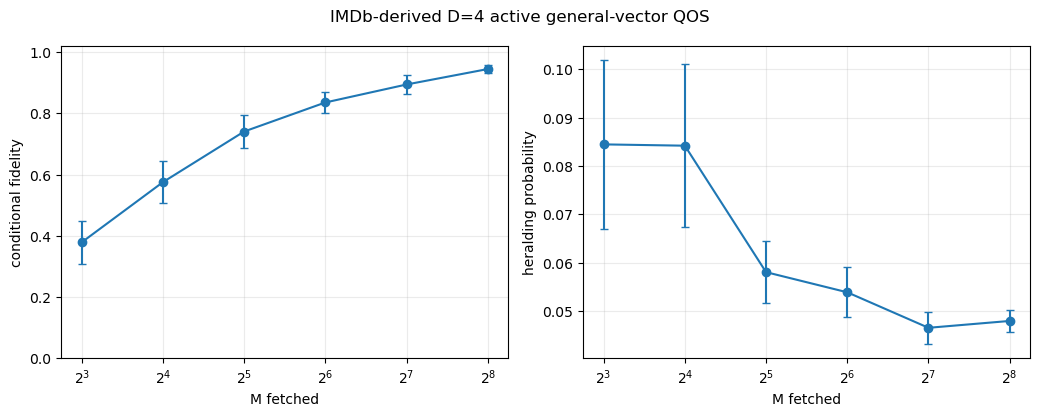

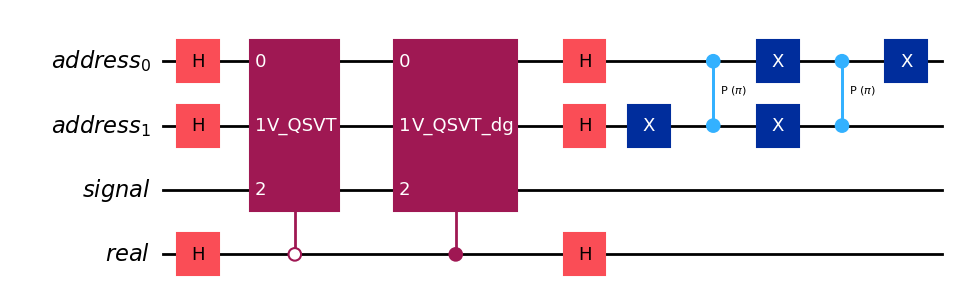

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].errorbar(
    scaling_summary["M_fetched"],
    scaling_summary["mean_conditional_fidelity"],
    yerr=1.96 * scaling_summary["std_conditional_fidelity"]
    / np.sqrt(scaling_summary["streams"]),
    marker="o", capsize=3,
)
axes[0].set_xscale("log", base=2)
axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel("M fetched")
axes[0].set_ylabel("conditional fidelity")
axes[0].grid(alpha=0.25)

axes[1].errorbar(
    scaling_summary["M_fetched"],
    scaling_summary["mean_success_probability"],
    yerr=1.96 * scaling_summary["std_success_probability"]
    / np.sqrt(scaling_summary["streams"]),
    marker="o", capsize=3,
)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("M fetched")
axes[1].set_ylabel("heralding probability")
axes[1].grid(alpha=0.25)

fig.suptitle("IMDb-derived D=4 active general-vector QOS")
fig.tight_layout()
fig.savefig(
    FIGURES / "imdb-d4-general-qsvt-scaling.png",
    dpi=180, bbox_inches="tight",
)
plt.show()

logical_figure = logical_prepare.draw(output="mpl", fold=-1)
logical_figure.savefig(
    CIRCUITS / "imdb-d4-general-qsvt-logical.png",
    dpi=180, bbox_inches="tight",
)
logical_prepare.draw(output="mpl", fold=-1)

![D=4 full general-vector QSVT logical circuit](../assets/circuits/imdb-d4-general-qsvt-logical.png)

![D=4 full general-vector QSVT scaling](../assets/figures/imdb-d4-general-qsvt-scaling.png)

图中的两个受控方块分别是 $V$ 与 $V^\dagger$，前后 Hadamard 在 `real`
辅助位上实现 $(V+V^\dagger)/2$。QASM bundle 已把这些方块完全分解成
`u1/u2/u3/cx`，所以云端收到的不是 opaque custom gate。

门数会很大，这本身就是重要结果：逻辑上只有 4 qubits，并不等于当前
NISQ 设备上线路很浅。先提交 $M=8$ 的 `verify` 也只是功能压力测试；
不要在没有 transpiled circuit 和 counts 时声称获得硬件优势。

## 5. Quafu-SQC 单任务提交

默认完全关闭。先查看 `manifest.csv`，只选择一个 experiment id。推荐从
`imdb_d4_general_qsvt_m8_verify` 开始；它仍被标记为 deep proof-of-principle，
不是低深度生产任务。

提交后应保存：

- task id；
- raw counts；
- transpiled QASM；
- 编译后二比特门数/depth；
- $p_{\rm succ}$；
- conditional fidelity 与成功事件数。

In [7]:
BACKEND = "Baihua"
COMPILER = "quarkcircuit"
SUBMIT_TO_HARDWARE = False
SELECTED_EXPERIMENT_ID = None

selected = None
if SELECTED_EXPERIMENT_ID is not None:
    selected = next(
        (
            entry for entry in manifest
            if entry["experiment_id"] == SELECTED_EXPERIMENT_ID
        ),
        None,
    )
    if selected is None:
        raise ValueError("Experiment id is not in manifest.json.")

if SUBMIT_TO_HARDWARE:
    if selected is None:
        raise ValueError(
            "Set exactly one SELECTED_EXPERIMENT_ID first."
        )
    from quafu import Task

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入 Quafu-SQC token（输入不会显示）: "
    )
    task_manager = Task(token)
    live_status = task_manager.status()
    print("Live backend status:", live_status)
    if not isinstance(live_status, dict):
        raise RuntimeError(
            "Fail-closed: backend status response is not a mapping."
        )
    backend_value = live_status.get(BACKEND)
    online_queue_value = (
        isinstance(backend_value, (int, np.integer))
        and not isinstance(backend_value, (bool, np.bool_))
        and int(backend_value) >= 0
    )
    online_label = (
        isinstance(backend_value, str)
        and backend_value.strip().lower()
        in {"online", "available", "idle"}
    )
    if not (online_queue_value or online_label):
        raise RuntimeError(
            f"Fail-closed: unexpected {BACKEND} state "
            f"{backend_value!r}."
        )

    selected_qasm_path = Path("..") / selected["qasm_path"]
    selected_qasm = selected_qasm_path.read_text(encoding="utf-8")
    observed_qasm_sha256 = hashlib.sha256(
        selected_qasm.encode("utf-8")
    ).hexdigest()
    if observed_qasm_sha256 != selected["qasm_sha256"]:
        raise RuntimeError(
            "QASM hash no longer matches the selected manifest entry."
        )
    parsed_selected = qasm2.loads(selected_qasm)
    selected_measurements = int(
        parsed_selected.count_ops().get("measure", 0)
    )
    if (
        parsed_selected.num_qubits != 4
        or parsed_selected.num_clbits != 4
        or selected_measurements != 4
    ):
        raise RuntimeError(
            "Selected QASM is not the audited 4q/4c/4-measure schema."
        )
    task = {
        "chip": BACKEND,
        "name": selected["experiment_id"],
        "circuit": selected_qasm,
        "shots": selected["S_shots"],
        "compile": True,
        "options": {
            "compiler": COMPILER,
            "correct": False,
            "open_dd": None,
            "target_qubits": [],
        },
    }
    submitted_task_id = task_manager.run(task)
    valid_task_id = (
        isinstance(submitted_task_id, (int, np.integer))
        and not isinstance(submitted_task_id, (bool, np.bool_))
        and int(submitted_task_id) > 0
    )
    if not valid_task_id:
        raise RuntimeError(
            "Submission did not return a positive integer task id; "
            f"received {submitted_task_id!r}."
        )
    submitted_task_id = int(submitted_task_id)
    receipt = {
        "experiment_id": selected["experiment_id"],
        "task_id": submitted_task_id,
        "submitted_at_utc": datetime.now(timezone.utc).isoformat(),
        "backend": BACKEND,
        "compiler": COMPILER,
        "shots": selected["S_shots"],
        "qasm_path": selected["qasm_path"],
        "qasm_sha256": observed_qasm_sha256,
    }
    receipt_dir = BUNDLE / "raw_results"
    receipt_dir.mkdir(parents=True, exist_ok=True)
    receipt_path = (
        receipt_dir
        / f"submission_receipt_{submitted_task_id}.json"
    )
    receipt_path.write_text(
        json.dumps(receipt, indent=2), encoding="utf-8"
    )
    print("Submitted one task:", submitted_task_id)
    print("Saved receipt:", receipt_path)
else:
    print("Hardware submission disabled.")

Hardware submission disabled.


### 取回真机结果

把返回的 task id 填入 `RESULT_TASK_IDS`。解析器会保存完整 raw JSON，并从
`count` 计算 heralding 与 verifier conditional fidelity；若平台返回
`transpiled` QASM，也会另外统计实际编译深度与二比特门数。

In [8]:
RESULT_TASK_IDS = {}
FETCH_REAL_RESULTS = False
RAW_RESULT_DIR = BUNDLE / "raw_results"
RAW_RESULT_DIR.mkdir(parents=True, exist_ok=True)


def returned_transpiled_metrics(qasm_text):
    if not qasm_text:
        return {
            "returned_depth": np.nan,
            "returned_two_qubit_gates": np.nan,
            "returned_two_qubit_depth": np.nan,
            "returned_three_plus_qubit_gates": np.nan,
            "returned_barriers": np.nan,
            "returned_ops": {},
            "returned_qasm_parse_reason": "missing_transpiled_qasm",
        }
    try:
        circuit = qasm2.loads(qasm_text)
    except Exception as exc:
        return {
            "returned_depth": np.nan,
            "returned_two_qubit_gates": np.nan,
            "returned_two_qubit_depth": np.nan,
            "returned_three_plus_qubit_gates": np.nan,
            "returned_barriers": np.nan,
            "returned_ops": {},
            "returned_qasm_parse_reason":
                f"parse_error:{type(exc).__name__}:{exc}",
        }
    gate_items = [
        item for item in circuit.data
        if isinstance(item.operation, Gate)
    ]
    two_qubit = sum(
        int(item.operation.num_qubits == 2)
        for item in gate_items
    )
    three_plus = sum(
        int(item.operation.num_qubits >= 3)
        for item in gate_items
    )
    two_qubit_depth = circuit.depth(
        filter_function=lambda item: (
            isinstance(item.operation, Gate)
            and item.operation.num_qubits == 2
        )
    )
    barrier_count = sum(
        int(item.operation.name == "barrier")
        for item in circuit.data
    )
    return {
        "returned_depth": circuit.depth(),
        "returned_two_qubit_gates": two_qubit,
        "returned_two_qubit_depth": two_qubit_depth,
        "returned_three_plus_qubit_gates": three_plus,
        "returned_barriers": barrier_count,
        "returned_ops": {
            str(k): int(v)
            for k, v in circuit.count_ops().items()
        },
        "returned_qasm_parse_reason": "ok",
    }


if FETCH_REAL_RESULTS:
    from quafu import Task

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入 Quafu-SQC token（输入不会显示）: "
    )
    task_manager = Task(token)
    parsed_rows = []
    for experiment_id, task_id in RESULT_TASK_IDS.items():
        entry = next(
            (
                item for item in manifest
                if item["experiment_id"] == experiment_id
            ),
            None,
        )
        if entry is None:
            raise ValueError(
                f"Unknown experiment id: {experiment_id!r}."
            )
        valid_task_id = (
            isinstance(task_id, (int, np.integer))
            and not isinstance(task_id, (bool, np.bool_))
            and int(task_id) > 0
        )
        if not valid_task_id:
            raise ValueError(
                "Every result task id must be a positive integer; "
                f"received {task_id!r} for {experiment_id!r}."
            )
        task_id = int(task_id)
        result = task_manager.result(task_id, timeout=60)
        if not isinstance(result, dict):
            result = {
                "status": "invalid_result_type",
                "finished": False,
                "error":
                    f"Expected mapping, got {type(result).__name__}: "
                    f"{result!r}",
            }
        raw_path = (
            RAW_RESULT_DIR / f"{experiment_id}_{task_id}.json"
        )
        raw_path.write_text(
            json.dumps(result, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
        result_status = str(result.get("status", "")).lower()
        if result_status in {"finished", "completed", "success"}:
            measurement = counts_metrics(result.get("count") or {})
        else:
            measurement = counts_metrics({})
            measurement["measurement_parse_reason"] = (
                f"nonfinished_status:{result.get('status')!r}"
            )
        if entry["circuit_kind"] == "prepare":
            measurement["shot_joint_target_probability"] = None
            measurement["shot_conditional_fidelity"] = None
        returned_qasm = result.get("transpiled", "")
        returned_qasm_path = None
        returned_qasm_sha256 = None
        if returned_qasm:
            returned_qasm_path = (
                RAW_RESULT_DIR
                / f"{experiment_id}_{task_id}_transpiled.qasm"
            )
            returned_qasm_path.write_text(
                returned_qasm, encoding="utf-8"
            )
            returned_qasm_sha256 = hashlib.sha256(
                returned_qasm.encode("utf-8")
            ).hexdigest()
        parsed_rows.append({
            "experiment_id": experiment_id,
            "task_id": task_id,
            "status": result.get("status"),
            "finished": result.get("finished"),
            "error": result.get("error", ""),
            "returned_qasm_path":
                str(returned_qasm_path)
                if returned_qasm_path else None,
            "returned_qasm_sha256": returned_qasm_sha256,
            **measurement,
            **returned_transpiled_metrics(
                returned_qasm
            ),
        })
    parsed_real_results = pd.DataFrame(parsed_rows)
    parsed_real_results.to_csv(
        BUNDLE / "parsed_real_results.csv", index=False
    )
    display(parsed_real_results)
else:
    print("Real-result retrieval disabled.")

Real-result retrieval disabled.


## 6. 结论

这本 notebook 闭合了一个此前缺失的证据链：

1. 向量来自真实 IMDb official-train；
2. active QOS 使用真实随机 sample stream；
3. NumPy 输出与 4-qubit 完整门级后选择分支逐振幅一致；
4. $p_{\rm succ}$ 与 $F_{\rm cond}$ 分开；
5. 生成的 QASM 完全分解并可由 Quafu-SQC 接口提交；
6. verifier 中理想态 inverse 被明确隔离，不冒充 QOS 制备。

它证明的是 $D=4$ full general-vector gate mechanism 的功能可实现性。
它没有执行 IMDb 规模的 matrix block encoding、ridge/QSVT solver、amplitude
amplification 或在线 streaming controller；这些仍是从 vector-sketch
primitive 到端到端量子分类器之间的工程缺口。